# <center>**Trabajo Práctico Número 2**</center>

### <center>**Recorridos en Ecobicis - Año 2024**</center>

#### <center>Análisis de datos - CEIA, Fiuba</center>

---

**Integrantes del grupo**

- Espínola, Carla
- Gambarte, Antonella

---


In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, f_regression, mutual_info_regression


In [3]:
df_recorridos_orig = pd.read_csv("../tp_datos/recorridos_data.csv")
print(df_recorridos_orig.shape)
df_recorridos_orig.head()

(3559283, 23)


,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,...,lat_estacion_destino,id_usuario,modelo_bicicleta,genero,edad_usuario,fecha_alta,has_dni,mes_origen,dia_semana_origen,edad_usuario_redondeada
0,20428222,568,2024-01-23 18:36:00,513,308 - SAN MARTIN II,Av. San Martín 5129,-58.490739,-34.597130,2024-01-23 18:45:28,498,...,-34.586598,992557,FIT,MALE,NaN,NaN,NaN,1,Tuesday,NaN
1,20431744,1355,2024-01-23 22:41:20,460,133 - BEIRO Y SEGUROLA,Segurola 3194,-58.511930,-34.607500,2024-01-23 23:03:55,382,...,-34.605431,320782,FIT,FEMALE,NaN,NaN,NaN,1,Tuesday,NaN
2,20429936,0,2024-01-23 20:06:22,467,328 - SARMIENTO II,Sarmiento 2037,-58.395893,-34.605514,2024-01-23 20:06:22,6,...,-34.628526,828678,FIT,FEMALE,NaN,NaN,NaN,1,Tuesday,NaN
3,20429976,0,2024-01-23 20:08:17,382,204 - Biarritz,Biarritz 2403,-58.477255,-34.605431,2024-01-23 20:08:17,460,...,-34.607500,320782,ICONIC,FEMALE,NaN,NaN,NaN,1,Tuesday,NaN
4,20424802,680,2024-01-23 15:18:39,137,137 - AZOPARDO Y CHILE,AZOPARDO 700,-58.367492,-34.615598,2024-01-23 15:29:59,150,...,-34.618755,861425,FIT,FEMALE,NaN,NaN,NaN,1,Tuesday,NaN


In [4]:
df_recorridos_orig['duracion_recorrido'] = df_recorridos_orig['duracion_recorrido'] / 60
df_recorridos_orig['duracion_recorrido'] = df_recorridos_orig['duracion_recorrido'].astype('int')

In [5]:
df_recorridos = df_recorridos_orig.copy()
df_recorridos.columns

Index(['id_recorrido', 'duracion_recorrido', 'fecha_origen_recorrido',
       'id_estacion_origen', 'nombre_estacion_origen',
       'direccion_estacion_origen', 'long_estacion_origen',
       'lat_estacion_origen', 'fecha_destino_recorrido', 'id_estacion_destino',
       'nombre_estacion_destino', 'direccion_estacion_destino',
       'long_estacion_destino', 'lat_estacion_destino', 'id_usuario',
       'modelo_bicicleta', 'genero', 'edad_usuario', 'fecha_alta', 'has_dni',
       'mes_origen', 'dia_semana_origen', 'edad_usuario_redondeada'],
      dtype='object')

## Eliminación de columnas

Al analizar las columnas disponibles y considerando el objetivo de predecir la duración del recorrido, identificamos la necesidad de eliminar aquellas variables que contienen información del futuro o que no estaría disponible en el momento de hacer la predicción.

Además, analizando los datos referidos a la ubicación de las estaciones, elegimos utilizar las coordenadas por lo que las direcciones van a ser eliminadas. Tambien vamos usar los id de las estaciones para identificarlas, por lo que el nombre ya no es necesario.


In [6]:
df_recorridos = df_recorridos.drop(['fecha_destino_recorrido'], axis=1) 
df_recorridos = df_recorridos.drop(['id_estacion_destino'], axis=1) 
df_recorridos = df_recorridos.drop(['nombre_estacion_destino'], axis=1) 
df_recorridos = df_recorridos.drop(['direccion_estacion_destino'], axis=1) 
df_recorridos = df_recorridos.drop(['long_estacion_destino'], axis=1) 
df_recorridos = df_recorridos.drop(['lat_estacion_destino'], axis=1) 

df_recorridos = df_recorridos.drop(['direccion_estacion_origen'], axis=1)  
df_recorridos = df_recorridos.drop(['nombre_estacion_origen'], axis=1) 

df_recorridos = df_recorridos.drop(['id_recorrido'], axis=1)
df_recorridos = df_recorridos.drop(['id_usuario'], axis=1)

df_recorridos.head()

,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,long_estacion_origen,lat_estacion_origen,modelo_bicicleta,genero,edad_usuario,fecha_alta,has_dni,mes_origen,dia_semana_origen,edad_usuario_redondeada
0,9,2024-01-23 18:36:00,513,-58.490739,-34.597130,FIT,MALE,NaN,NaN,NaN,1,Tuesday,NaN
1,22,2024-01-23 22:41:20,460,-58.511930,-34.607500,FIT,FEMALE,NaN,NaN,NaN,1,Tuesday,NaN
2,0,2024-01-23 20:06:22,467,-58.395893,-34.605514,FIT,FEMALE,NaN,NaN,NaN,1,Tuesday,NaN
3,0,2024-01-23 20:08:17,382,-58.477255,-34.605431,ICONIC,FEMALE,NaN,NaN,NaN,1,Tuesday,NaN
4,11,2024-01-23 15:18:39,137,-58.367492,-34.615598,FIT,FEMALE,NaN,NaN,NaN,1,Tuesday,NaN


In [7]:
df_recorridos['fecha_origen_recorrido'] = pd.to_datetime(df_recorridos['fecha_origen_recorrido'])
df_recorridos['fecha_alta'] = pd.to_datetime(df_recorridos['fecha_alta'])
df_recorridos['has_dni'] = df_recorridos['has_dni'].map({'Yes': True, 'No': False, np.nan: np.nan})
df_recorridos['modelo_bicicleta'] = df_recorridos['modelo_bicicleta'].astype('category')
df_recorridos['genero'] = df_recorridos['genero'].astype('category')

df_recorridos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3559283 entries, 0 to 3559282
Data columns (total 13 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   duracion_recorrido       int64         
 1   fecha_origen_recorrido   datetime64[ns]
 2   id_estacion_origen       int64         
 3   long_estacion_origen     float64       
 4   lat_estacion_origen      float64       
 5   modelo_bicicleta         category      
 6   genero                   category      
 7   edad_usuario             float64       
 8   fecha_alta               datetime64[ns]
 9   has_dni                  object        
 10  mes_origen               int64         
 11  dia_semana_origen        object        
 12  edad_usuario_redondeada  float64       
dtypes: category(2), datetime64[ns](2), float64(4), int64(3), object(2)
memory usage: 305.5+ MB


#### Fecha alta
La variable fecha_alta tiene un porcentaje muy alto de nulos y no es relevante para el objetivo a predecir (duración del recorrido) dentro del tiempo habilitado para usar una ecobici.

In [8]:
df_recorridos[df_recorridos.duracion_recorrido > 45].shape

(230319, 13)

In [9]:
aux = df_recorridos[df_recorridos.duracion_recorrido <= 45][['duracion_recorrido']].copy()
aux['dias_desde_alta'] = (df_recorridos['fecha_origen_recorrido'] - df_recorridos['fecha_alta']).dt.days

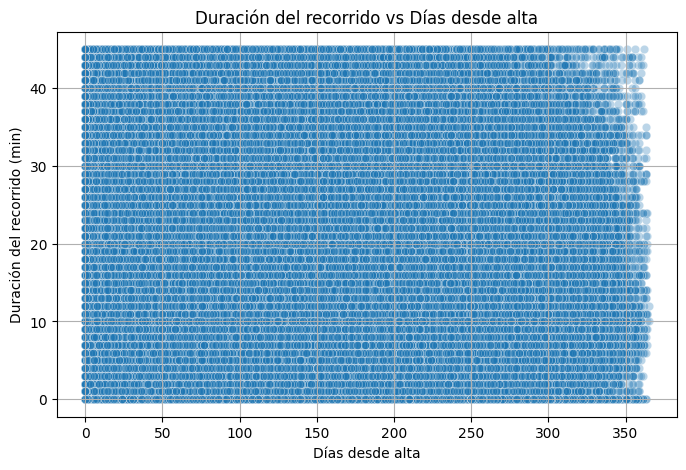

In [10]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=aux, x='dias_desde_alta', y='duracion_recorrido', alpha=0.3)
plt.title('Duración del recorrido vs Días desde alta')
plt.xlabel('Días desde alta')
plt.ylabel('Duración del recorrido (min)')
plt.grid(True)
plt.show()

In [11]:
correlacion = aux['dias_desde_alta'].corr(aux['duracion_recorrido'], method='pearson')
print("Correlación de Pearson entre días desde alta y duración del recorrido:", correlacion)

correlacion = aux['dias_desde_alta'].corr(aux['duracion_recorrido'], method='spearman')
print("Correlación de Spearman entre días desde alta y duración del recorrido:", correlacion)

correlacion = aux['dias_desde_alta'].corr(aux['duracion_recorrido'], method='kendall')
print("Correlación de Kendall entre días desde alta y duración del recorrido:", correlacion)

Correlación de Pearson entre días desde alta y duración del recorrido: -0.08463909889725546
Correlación de Spearman entre días desde alta y duración del recorrido: -0.1058417450793423
Correlación de Kendall entre días desde alta y duración del recorrido: -0.07350912925736248


In [12]:
df_recorridos = df_recorridos.drop(['fecha_alta'], axis=1)

df_recorridos.head()

,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,long_estacion_origen,lat_estacion_origen,modelo_bicicleta,genero,edad_usuario,has_dni,mes_origen,dia_semana_origen,edad_usuario_redondeada
0,9,2024-01-23 18:36:00,513,-58.490739,-34.597130,FIT,MALE,NaN,NaN,1,Tuesday,NaN
1,22,2024-01-23 22:41:20,460,-58.511930,-34.607500,FIT,FEMALE,NaN,NaN,1,Tuesday,NaN
2,0,2024-01-23 20:06:22,467,-58.395893,-34.605514,FIT,FEMALE,NaN,NaN,1,Tuesday,NaN
3,0,2024-01-23 20:08:17,382,-58.477255,-34.605431,ICONIC,FEMALE,NaN,NaN,1,Tuesday,NaN
4,11,2024-01-23 15:18:39,137,-58.367492,-34.615598,FIT,FEMALE,NaN,NaN,1,Tuesday,NaN


#### Duración del recorrido

Dado que el tiempo permitido para el uso de una ecobici de màximo de 45 minutos, vamos a acotar el dataset a ese tiempo.

<Axes: ylabel='Frequency'>

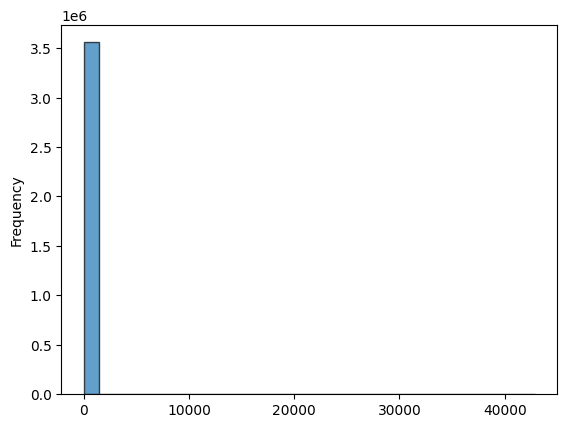

In [13]:
df_recorridos.duracion_recorrido.plot(kind='hist', bins=30, edgecolor='black', alpha=0.7)

<Axes: ylabel='Frequency'>

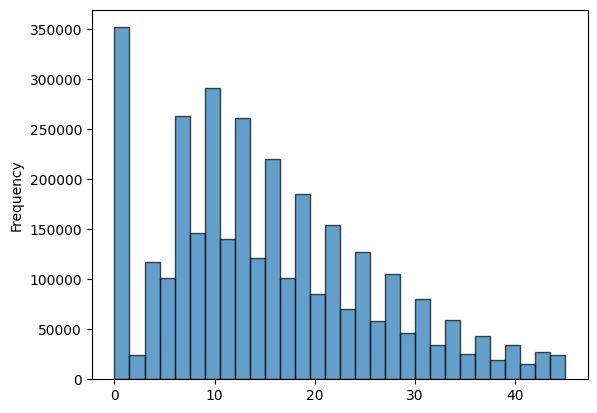

In [14]:
df_recorridos.duracion_recorrido[df_recorridos.duracion_recorrido <= 45].plot(kind='hist', bins=30, edgecolor='black', alpha=0.7)

In [15]:
print(df_recorridos.shape)
df_recorridos = df_recorridos[df_recorridos.duracion_recorrido <= 45]
print(df_recorridos.shape)

(3559283, 12)
(3328964, 12)


## División del dataset

In [16]:
X = df_recorridos.drop("duracion_recorrido", axis=1)
y = df_recorridos["duracion_recorrido"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
X_train.head()

,fecha_origen_recorrido,id_estacion_origen,long_estacion_origen,lat_estacion_origen,modelo_bicicleta,genero,edad_usuario,has_dni,mes_origen,dia_semana_origen,edad_usuario_redondeada
3425751,2024-05-13 15:51:33,474,-58.503020,-34.610892,FIT,OTHER,NaN,NaN,5,Monday,NaN
1773202,2024-11-21 20:44:04,324,-58.484056,-34.578933,FIT,MALE,NaN,NaN,11,Thursday,NaN
1382238,2024-03-14 20:11:24,254,-58.441351,-34.620794,FIT,FEMALE,NaN,NaN,3,Thursday,NaN
1685983,2024-06-13 18:14:20,86,-58.401681,-34.621268,FIT,MALE,NaN,NaN,6,Thursday,NaN
2177682,2024-02-20 17:39:19,152,-58.359631,-34.618164,ICONIC,MALE,NaN,NaN,2,Tuesday,NaN


## Imputación

A continuación, mostramos los porcentajes de nulos para las variables del dataframe resultante luego de la eliminación de columnas innecesarias


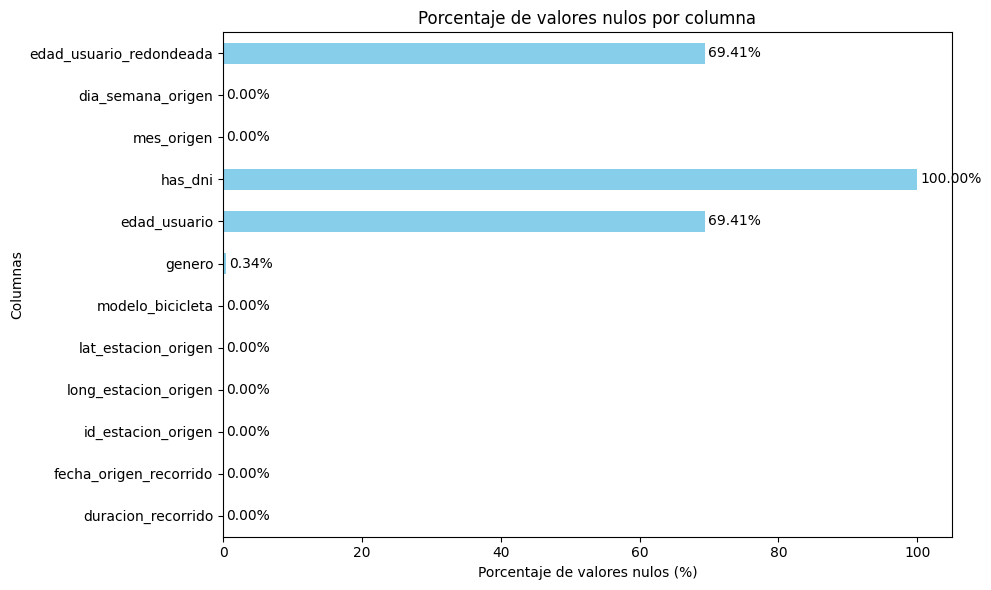

In [18]:
porcentaje_nulos = df_recorridos.isna().mean().round(4) * 100

plt.figure(figsize=(10, 6))
porcentaje_nulos.plot(kind='barh', color='skyblue')

plt.title('Porcentaje de valores nulos por columna')
plt.xlabel('Porcentaje de valores nulos (%)')
plt.ylabel('Columnas')

for index, value in enumerate(porcentaje_nulos):
    plt.text(value + 0.5, index, f'{value:.2f}%', va='center')

plt.tight_layout()
plt.show()

Observamos que para la variable has_dni, no exite ningún valor. Por lo que eliminaremos esa variable. 

#### Edad de usuario
Vamos a eliminar la columna edad_usuario y vamos a quedarnos con la columna edad_usuario_redondeada.


In [19]:
X_train = X_train.drop(['has_dni'], axis=1) 
X_train = X_train.drop(['edad_usuario'], axis=1) 

X_test = X_test.drop(['has_dni'], axis=1) 
X_test = X_test.drop(['edad_usuario'], axis=1) 

Para el caso de la edad del usuario existe porcentaje alto de nulos. Dado esto, se decide no imputar la variable con un valor, sino más bien categorizar la varaible y dejar los valores nulos como "-1". 

Posteriormente, en la etapa de modelado, se evaluará si la variable aprota información o solo añade ruido en función de su relevancia para el desempeño del modelo.

Como la distribución de esta variable es asimétrica, decidimos usar el método por puntos de corte para discretizar.


In [20]:
# Inicializar el discretizador (4 cuantiles)
kbin = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')

# Fit con datos no nulos de X_train
kbin.fit(X_train[["edad_usuario_redondeada"]].dropna())

# Discretizamos en X_train
X_train[f'{"edad_usuario_redondeada"}_bin'] = -1  # valor para los nulos
mask_train = X_train["edad_usuario_redondeada"].notna()
X_train.loc[mask_train, f'{"edad_usuario_redondeada"}_bin'] = kbin.transform(X_train[["edad_usuario_redondeada"]][mask_train]).astype(int)

# Discretizamos en X_test
X_test[f'{"edad_usuario_redondeada"}_bin'] = -1
mask_test = X_test["edad_usuario_redondeada"].notna()
X_test.loc[mask_test, f'{"edad_usuario_redondeada"}_bin'] = kbin.transform(X_test[["edad_usuario_redondeada"]][mask_test]).astype(int)

# Eliminamos la columna edad_usuario_redondeada
X_train = X_train.drop(['edad_usuario_redondeada'], axis=1) 
X_test = X_test.drop(['edad_usuario_redondeada'], axis=1) 

In [21]:
X_train.head()

,fecha_origen_recorrido,id_estacion_origen,long_estacion_origen,lat_estacion_origen,modelo_bicicleta,genero,mes_origen,dia_semana_origen,edad_usuario_redondeada_bin
3425751,2024-05-13 15:51:33,474,-58.503020,-34.610892,FIT,OTHER,5,Monday,-1
1773202,2024-11-21 20:44:04,324,-58.484056,-34.578933,FIT,MALE,11,Thursday,-1
1382238,2024-03-14 20:11:24,254,-58.441351,-34.620794,FIT,FEMALE,3,Thursday,-1
1685983,2024-06-13 18:14:20,86,-58.401681,-34.621268,FIT,MALE,6,Thursday,-1
2177682,2024-02-20 17:39:19,152,-58.359631,-34.618164,ICONIC,MALE,2,Tuesday,-1


#### Género
En cuanto a los faltates de la variable **género**, recordemos que en el tp anterior concluímos que los faltates eran de tipo MAR para esta variable. Vamos a ver la distribución por género.


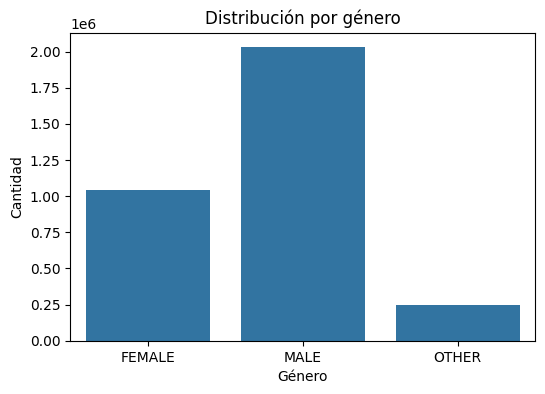

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_recorridos, x='genero')
plt.title('Distribución por género')
plt.xlabel('Género')
plt.ylabel('Cantidad')
plt.show()


Dada la distribución que tienen los datos y el bajo porcentaje de faltantes para esta variable, vamos a imputar con la moda.


In [23]:
# Definimos el imputador con estrategia 'most_frequent' (moda)
imputer_gender = SimpleImputer(strategy='most_frequent')

# Ajustamos train
X_train[['genero']] = imputer_gender.fit_transform(X_train[['genero']])

# Transformamos test con lo aprendido en train
X_test[['genero']] = imputer_gender.transform(X_test[['genero']])

In [24]:
X_train.head()

,fecha_origen_recorrido,id_estacion_origen,long_estacion_origen,lat_estacion_origen,modelo_bicicleta,genero,mes_origen,dia_semana_origen,edad_usuario_redondeada_bin
3425751,2024-05-13 15:51:33,474,-58.503020,-34.610892,FIT,OTHER,5,Monday,-1
1773202,2024-11-21 20:44:04,324,-58.484056,-34.578933,FIT,MALE,11,Thursday,-1
1382238,2024-03-14 20:11:24,254,-58.441351,-34.620794,FIT,FEMALE,3,Thursday,-1
1685983,2024-06-13 18:14:20,86,-58.401681,-34.621268,FIT,MALE,6,Thursday,-1
2177682,2024-02-20 17:39:19,152,-58.359631,-34.618164,ICONIC,MALE,2,Tuesday,-1


## Outliers

Ya tratamos previamente las variables que no estaban dentro de lo esperado.


## Feature engineering
creación de features de día y hora que pueden indicar un horario o día del mes de uso más frecuente

In [25]:
X_train['dia_origen'] = X_train['fecha_origen_recorrido'].dt.day
X_train['hora_origen'] = X_train['fecha_origen_recorrido'].dt.hour

X_test['dia_origen'] = X_test['fecha_origen_recorrido'].dt.day
X_test['hora_origen'] = X_test['fecha_origen_recorrido'].dt.hour
X_train.head()

,fecha_origen_recorrido,id_estacion_origen,long_estacion_origen,lat_estacion_origen,modelo_bicicleta,genero,mes_origen,dia_semana_origen,edad_usuario_redondeada_bin,dia_origen,hora_origen
3425751,2024-05-13 15:51:33,474,-58.503020,-34.610892,FIT,OTHER,5,Monday,-1,13,15
1773202,2024-11-21 20:44:04,324,-58.484056,-34.578933,FIT,MALE,11,Thursday,-1,21,20
1382238,2024-03-14 20:11:24,254,-58.441351,-34.620794,FIT,FEMALE,3,Thursday,-1,14,20
1685983,2024-06-13 18:14:20,86,-58.401681,-34.621268,FIT,MALE,6,Thursday,-1,13,18
2177682,2024-02-20 17:39:19,152,-58.359631,-34.618164,ICONIC,MALE,2,Tuesday,-1,20,17


In [26]:
# Transformación de dia_semana_origen a numérica
mapa_dias = {
    'Lunes': 0,
    'Martes': 1,
    'Miércoles': 2,
    'Jueves': 3,
    'Viernes': 4,
    'Sábado': 5,
    'Domingo': 6
}

X_train['dia_semana_origen'] = X_train['dia_semana_origen'].map(mapa_dias)
X_test['dia_semana_origen'] = X_test['dia_semana_origen'].map(mapa_dias)

In [27]:
# Calculamos día de la semana desde la fecha para los faltantes en dia_semana_origen
dia_semana_calculado = X_train['fecha_origen_recorrido'].dt.dayofweek
# Completamos solo los nulos
X_train['dia_semana_origen'] = X_train['dia_semana_origen'].fillna(dia_semana_calculado)

dia_semana_calculado = X_test['fecha_origen_recorrido'].dt.dayofweek
X_test['dia_semana_origen'] = X_test['dia_semana_origen'].fillna(dia_semana_calculado)


In [28]:
#Elimino fecha_origen_recorrido
X_train = X_train.drop(['fecha_origen_recorrido'], axis=1)
X_test = X_test.drop(['fecha_origen_recorrido'], axis=1)

In [29]:
X_train.head()

,id_estacion_origen,long_estacion_origen,lat_estacion_origen,modelo_bicicleta,genero,mes_origen,dia_semana_origen,edad_usuario_redondeada_bin,dia_origen,hora_origen
3425751,474,-58.503020,-34.610892,FIT,OTHER,5,0.0,-1,13,15
1773202,324,-58.484056,-34.578933,FIT,MALE,11,3.0,-1,21,20
1382238,254,-58.441351,-34.620794,FIT,FEMALE,3,3.0,-1,14,20
1685983,86,-58.401681,-34.621268,FIT,MALE,6,3.0,-1,13,18
2177682,152,-58.359631,-34.618164,ICONIC,MALE,2,1.0,-1,20,17


## Codificación

En cuanto a mes_origen, dia_semana_origen, dia_origen y hora_origen, vamos a usar la técnica seno y coseno para que el modelo entienda que, por ejemplo, la hora 23 y la 0 están “cerca”, o que diciembre y enero son meses consecutivos.

In [30]:
# Mes
X_train['mes_origen_sin'] = np.sin(2 * np.pi * X_train['mes_origen'] / 12)
X_train['mes_origen_cos'] = np.cos(2 * np.pi * X_train['mes_origen'] / 12)

# Día de la semana
X_train['dia_semana_origen_sin'] = np.sin(2 * np.pi * X_train['dia_semana_origen'] / 7)
X_train['dia_semana_origen_cos'] = np.cos(2 * np.pi * X_train['dia_semana_origen'] / 7)

# Día del mes
X_train['dia_origen_sin'] = np.sin(2 * np.pi * X_train['dia_origen'] / 31)
X_train['dia_origen_cos'] = np.cos(2 * np.pi * X_train['dia_origen'] / 31)

# Hora
X_train['hora_origen_sin'] = np.sin(2 * np.pi * X_train['hora_origen'] / 24)
X_train['hora_origen_cos'] = np.cos(2 * np.pi * X_train['hora_origen'] / 24)

# Aplicar las mismas transformaciones a X_test
X_test['mes_origen_sin'] = np.sin(2 * np.pi * X_test['mes_origen'] / 12)
X_test['mes_origen_cos'] = np.cos(2 * np.pi * X_test['mes_origen'] / 12)

X_test['dia_semana_origen_sin'] = np.sin(2 * np.pi * X_test['dia_semana_origen'] / 7)
X_test['dia_semana_origen_cos'] = np.cos(2 * np.pi * X_test['dia_semana_origen'] / 7)

X_test['dia_origen_sin'] = np.sin(2 * np.pi * X_test['dia_origen'] / 31)
X_test['dia_origen_cos'] = np.cos(2 * np.pi * X_test['dia_origen'] / 31)

X_test['hora_origen_sin'] = np.sin(2 * np.pi * X_test['hora_origen'] / 24)
X_test['hora_origen_cos'] = np.cos(2 * np.pi * X_test['hora_origen'] / 24)


In [31]:
#Elimino mes_origen, dia_semana_origen, dia_origen y hora_origen
X_train = X_train.drop(['mes_origen', 'dia_semana_origen', 'dia_origen', 'hora_origen'], axis=1)
X_test = X_test.drop(['mes_origen', 'dia_semana_origen', 'dia_origen', 'hora_origen'], axis=1)

In [32]:
X_train.head()

,id_estacion_origen,long_estacion_origen,lat_estacion_origen,modelo_bicicleta,genero,edad_usuario_redondeada_bin,mes_origen_sin,mes_origen_cos,dia_semana_origen_sin,dia_semana_origen_cos,dia_origen_sin,dia_origen_cos,hora_origen_sin,hora_origen_cos
3425751,474,-58.503020,-34.610892,FIT,OTHER,-1,5.000000e-01,-8.660254e-01,0.000000,1.000000,0.485302,-0.874347,-0.707107,-7.071068e-01
1773202,324,-58.484056,-34.578933,FIT,MALE,-1,-5.000000e-01,8.660254e-01,0.433884,-0.900969,-0.897805,-0.440394,-0.866025,5.000000e-01
1382238,254,-58.441351,-34.620794,FIT,FEMALE,-1,1.000000e+00,6.123234e-17,0.433884,-0.900969,0.299363,-0.954139,-0.866025,5.000000e-01
1685983,86,-58.401681,-34.621268,FIT,MALE,-1,1.224647e-16,-1.000000e+00,0.433884,-0.900969,0.485302,-0.874347,-1.000000,-1.836970e-16
2177682,152,-58.359631,-34.618164,ICONIC,MALE,-1,8.660254e-01,5.000000e-01,0.781831,0.623490,-0.790776,-0.612106,-0.965926,-2.588190e-01


Procedemos a codificar las variables categóricas. Por tratarse de variables categóricas de baja cardinalidad usaremos One-Hot Encoding para modelo_bicicleta y genero.

In [33]:
# One-Hot Encoding para modelo_bicicleta y genero
ohe = OneHotEncoder(drop='first', sparse_output=False)

# Ajustar y transformar en X_train
ohe_cols = ['modelo_bicicleta', 'genero']
X_train_ohe = ohe.fit_transform(X_train[ohe_cols])
X_train_ohe_df = pd.DataFrame(X_train_ohe, columns=ohe.get_feature_names_out(ohe_cols), index=X_train.index)
X_train = pd.concat([X_train.drop(ohe_cols, axis=1), X_train_ohe_df], axis=1)

# Transformar en X_test
X_test_ohe = ohe.transform(X_test[ohe_cols])
X_test_ohe_df = pd.DataFrame(X_test_ohe, columns=ohe.get_feature_names_out(ohe_cols), index=X_test.index)
X_test = pd.concat([X_test.drop(ohe_cols, axis=1), X_test_ohe_df], axis=1)

In [34]:
X_train.head()

,id_estacion_origen,long_estacion_origen,lat_estacion_origen,edad_usuario_redondeada_bin,mes_origen_sin,mes_origen_cos,dia_semana_origen_sin,dia_semana_origen_cos,dia_origen_sin,dia_origen_cos,hora_origen_sin,hora_origen_cos,modelo_bicicleta_ICONIC,genero_MALE,genero_OTHER
3425751,474,-58.503020,-34.610892,-1,5.000000e-01,-8.660254e-01,0.000000,1.000000,0.485302,-0.874347,-0.707107,-7.071068e-01,0.0,0.0,1.0
1773202,324,-58.484056,-34.578933,-1,-5.000000e-01,8.660254e-01,0.433884,-0.900969,-0.897805,-0.440394,-0.866025,5.000000e-01,0.0,1.0,0.0
1382238,254,-58.441351,-34.620794,-1,1.000000e+00,6.123234e-17,0.433884,-0.900969,0.299363,-0.954139,-0.866025,5.000000e-01,0.0,0.0,0.0
1685983,86,-58.401681,-34.621268,-1,1.224647e-16,-1.000000e+00,0.433884,-0.900969,0.485302,-0.874347,-1.000000,-1.836970e-16,0.0,1.0,0.0
2177682,152,-58.359631,-34.618164,-1,8.660254e-01,5.000000e-01,0.781831,0.623490,-0.790776,-0.612106,-0.965926,-2.588190e-01,1.0,1.0,0.0


### Normalización

In [35]:
X_train.shape

(2663171, 15)

In [36]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_num = scaler.fit_transform(X_train)
X_test_num = scaler.transform(X_test)
X_train_final = pd.DataFrame(X_train_num, columns=X_train.columns, index=X_train.index)
X_test_final = pd.DataFrame(X_test_num, columns=X_test.columns, index=X_test.index)
X_train_final.shape

(2663171, 15)

In [37]:
X_train_final.head()

,id_estacion_origen,long_estacion_origen,lat_estacion_origen,edad_usuario_redondeada_bin,mes_origen_sin,mes_origen_cos,dia_semana_origen_sin,dia_semana_origen_cos,dia_origen_sin,dia_origen_cos,hora_origen_sin,hora_origen_cos,modelo_bicicleta_ICONIC,genero_MALE,genero_OTHER
3425751,0.820870,0.140288,0.508853,0.0,0.750000,0.066987,0.500000,1.000000e+00,0.742963,0.060416,0.146447,0.146447,0.0,0.0,1.0
1773202,0.560000,0.250782,0.720392,0.0,0.250000,0.933013,0.722521,5.551115e-17,0.050521,0.277951,0.066987,0.750000,0.0,1.0,0.0
1382238,0.438261,0.499597,0.443304,0.0,1.000000,0.500000,0.722521,5.551115e-17,0.649874,0.020417,0.066987,0.750000,0.0,0.0,0.0
1685983,0.146087,0.730731,0.440169,0.0,0.500000,0.000000,0.722521,5.551115e-17,0.742963,0.060416,0.000000,0.500000,0.0,1.0,0.0
2177682,0.260870,0.975729,0.460712,0.0,0.933013,0.750000,0.900969,8.019377e-01,0.104104,0.191874,0.017037,0.370590,1.0,1.0,0.0


### Selección de features

In [38]:
num_features = ['id_estacion_origen', 'long_estacion_origen', 'lat_estacion_origen',
       'edad_usuario_redondeada_bin', 'mes_origen_sin', 'mes_origen_cos',
       'dia_semana_origen_sin', 'dia_semana_origen_cos', 'dia_origen_sin',
       'dia_origen_cos', 'hora_origen_sin', 'hora_origen_cos']
cat_features = ['modelo_bicicleta_ICONIC','genero_MALE','genero_OTHER']

#### Correlación

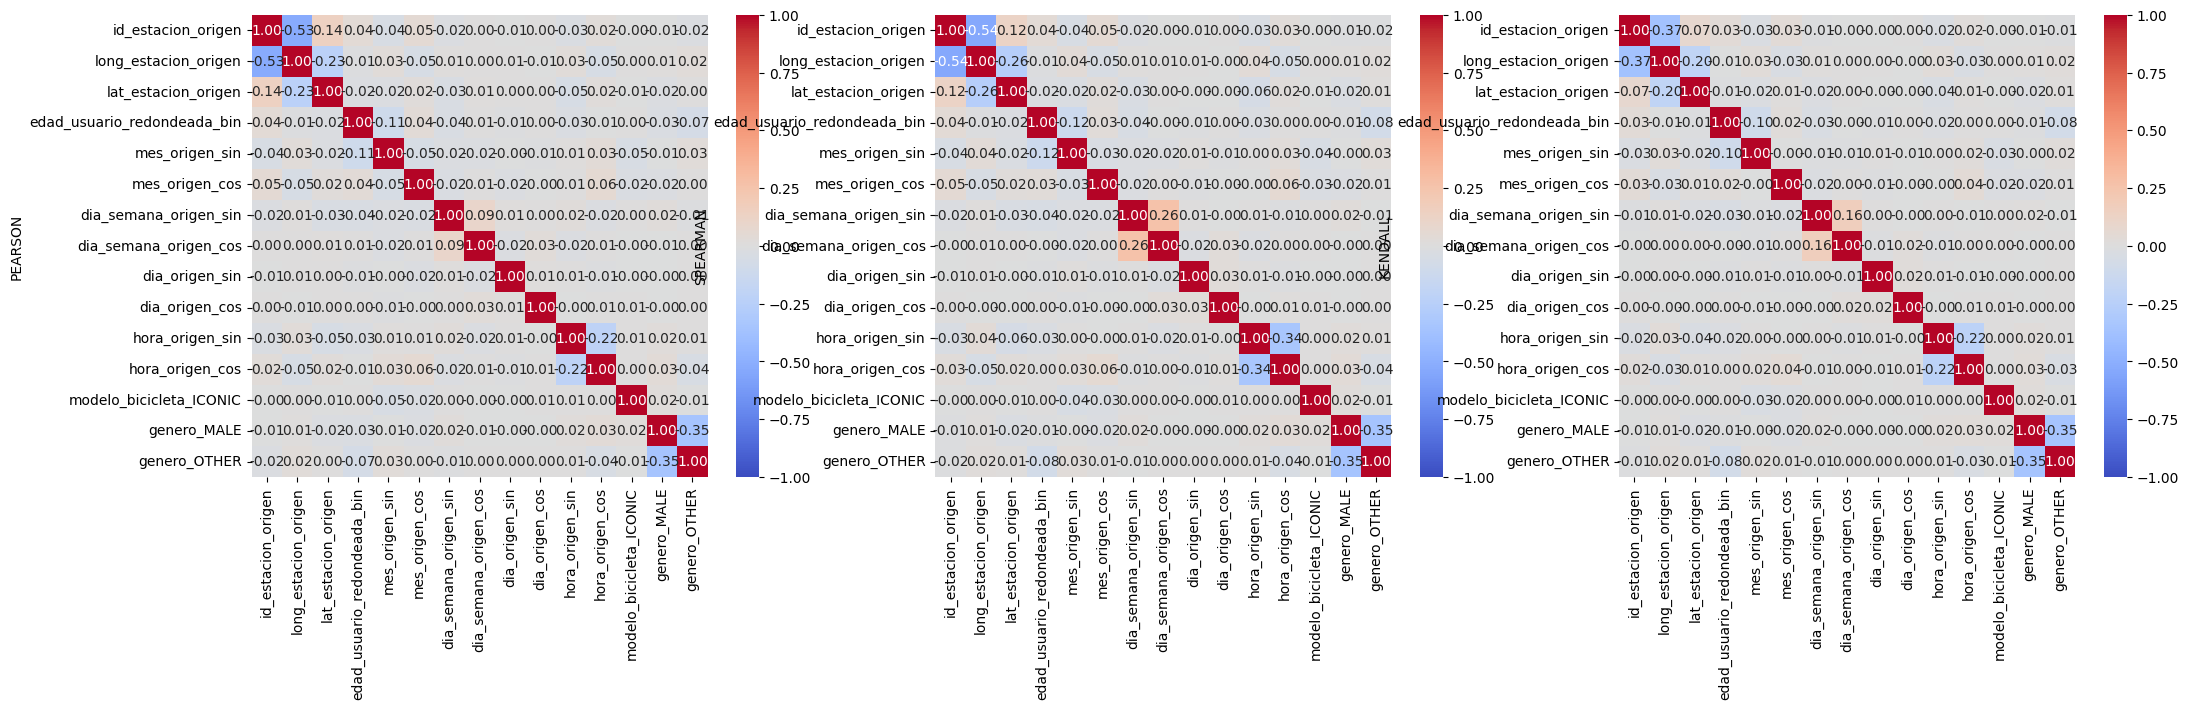

In [39]:
plt.figure(figsize=(25,6))

plt.subplot(1, 3, 1)
sns.heatmap(
    X_train_final.corr(numeric_only=False), 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm",  
    center=0, 
    vmin=-1, 
    vmax=1)
plt.ylabel('PEARSON')

plt.subplot(1, 3, 2)
sns.heatmap(
    X_train_final.corr(method='spearman', numeric_only=False),
    annot=True, 
    fmt=".2f",  
    cmap="coolwarm",  
    center=0, 
    vmin=-1, 
    vmax=1,)
plt.ylabel('SPEARMAN')

plt.subplot(1, 3, 3)
sns.heatmap(
    X_train_final.corr(method='kendall', numeric_only=False), 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm",
    center=0, 
    vmin=-1, 
    vmax=1,)
plt.ylabel('KENDALL')

plt.show()

Hay correlación entre el id de la estación y su pocisión geográfica, los distintos géneros y el seno y el coseno de las varaibles temporales, lo cual tiene mucho sentido.

#### Umbral de varianza

In [40]:
X_train_final.var()


id_estacion_origen             0.082842
long_estacion_origen           0.049631
lat_estacion_origen            0.025634
edad_usuario_redondeada_bin    0.112096
mes_origen_sin                 0.128270
mes_origen_cos                 0.120212
dia_semana_origen_sin          0.102441
dia_semana_origen_cos          0.154627
dia_origen_sin                 0.127939
dia_origen_cos                 0.122872
hora_origen_sin                0.114573
hora_origen_cos                0.093587
modelo_bicicleta_ICONIC        0.199218
genero_MALE                    0.237272
genero_OTHER                   0.067874
dtype: float64

In [41]:
selector = VarianceThreshold(threshold=0.02) 
X_train_selected = selector.fit_transform(X_train_final)
print("\nCaracterísticas seleccionadas (varianza):", X_train_final.columns[selector.get_support()].tolist())

# Aplico la selección también a test
X_test_selected = selector.transform(X_test_final)


Características seleccionadas (varianza): ['id_estacion_origen', 'long_estacion_origen', 'lat_estacion_origen', 'edad_usuario_redondeada_bin', 'mes_origen_sin', 'mes_origen_cos', 'dia_semana_origen_sin', 'dia_semana_origen_cos', 'dia_origen_sin', 'dia_origen_cos', 'hora_origen_sin', 'hora_origen_cos', 'modelo_bicicleta_ICONIC', 'genero_MALE', 'genero_OTHER']


No se descartan variables por poca varianza

#### ANOVA

Obtenemos las 10 variables con mayor poder predictivo

In [42]:
X_train_final.shape

(2663171, 15)

In [43]:
selector_anova = SelectKBest(score_func=f_regression, k=10)
X_train_num_best = selector_anova.fit_transform(X_train_final[num_features], y_train)
selected_indices = selector_anova.get_support()
selected_features = X_train_final[num_features].columns[selected_indices]
scores = selector_anova.scores_[selected_indices]
print("Selected features:", selected_features)
print(f"Numéricas antes de filtrar: {X_train_final[num_features].columns}")
print("\nCaracterísticas seleccionadas (ANOVA):")
for feature, score in zip(selected_features, scores):
    print(f"{feature}: {score:.4f}")

# Aplicar el filtro a los datos de test:
X_test_num_best = selector_anova.transform(X_test_final[num_features])

Selected features: Index(['id_estacion_origen', 'long_estacion_origen', 'lat_estacion_origen',
       'edad_usuario_redondeada_bin', 'mes_origen_sin', 'mes_origen_cos',
       'dia_semana_origen_sin', 'dia_semana_origen_cos', 'hora_origen_sin',
       'hora_origen_cos'],
      dtype='object')
Numéricas antes de filtrar: Index(['id_estacion_origen', 'long_estacion_origen', 'lat_estacion_origen',
       'edad_usuario_redondeada_bin', 'mes_origen_sin', 'mes_origen_cos',
       'dia_semana_origen_sin', 'dia_semana_origen_cos', 'dia_origen_sin',
       'dia_origen_cos', 'hora_origen_sin', 'hora_origen_cos'],
      dtype='object')

Características seleccionadas (ANOVA):
id_estacion_origen: 1114.9361
long_estacion_origen: 2287.9177
lat_estacion_origen: 7.0300
edad_usuario_redondeada_bin: 9062.1074
mes_origen_sin: 752.8423
mes_origen_cos: 3916.8989
dia_semana_origen_sin: 16778.8924
dia_semana_origen_cos: 322.8696
hora_origen_sin: 23873.0611
hora_origen_cos: 3411.1078


Se observa una diferencia bastante amplia entre las de menor y las de mayor poder predictivo. Por ejemplo, parece ser que con long_estacion_origen es suficiente para lograr un poder predictivo sobre el target quedando lat_estacion_origen con un poder predictivo muy bajo.

#### Información mutua

In [ ]:
selector_mi = SelectKBest(score_func=mutual_info_regression, k=15) 
X_train_best = selector_mi.fit_transform(X_train_final, y_train)
selected_indices = selector_mi.get_support()
selected_features = X_train_final.columns[selected_indices]
scores = selector_mi.scores_[selected_indices]
print("\nCaracterísticas seleccionadas (Inf. mutua):")
for feature, score in zip(selected_features, scores):
    print(f"{feature}: {score:.4f}")

X_test_best = selector_mi.transform(X_test_final)